In [39]:
%matplotlib inline


The generalized plasma dispersion function
==========================================

Let's import some basics (and `plasmapy`!)


In [40]:
import matplotlib.pyplot as plt
import numpy as np
import astropy.units as u

In [41]:
from plasmapy.dispersion.dispersion_functions import (plasma_dispersion_1D_dist,
                                                      plasma_dispersion_1D_dist_arr,
                                                      plasma_dispersion_1D_dist_deriv,
                                                      plasma_dispersion_1D_dist_deriv_arr,
                                                      plasma_dispersion_func,
                                                      plasma_dispersion_func_deriv)
from plasmapy.formulary.distribution import Maxwellian_1D, Generalized_Gaussian_1D
from plasmapy.formulary.frequencies import plasma_frequency
from plasmapy.formulary.speeds import thermal_speed, generalized_gaussian_thermal_speed

We'll now make some sample data to visualize the dispersion function:



In [42]:
x = np.linspace(-2, 2, 40)
X, Y = np.meshgrid(x, x)
Z = X + 1j * Y
print(Z.shape)

(40, 40)


Create a 1D distribution function and apply variables so that only velocity is left as an argument.

In [43]:
particle = "e-"
Te = 10 * 11604 * u.K
vth = thermal_speed(Te, particle=particle, method="most_probable")
dfunc = lambda v: Maxwellian_1D(v=v,
                                T=Te,
                                particle=particle,
                                v_drift=0,
                                vTh=vth,
                               )


We'll also calculate the plasma frequency to help speed up the computation of the dispersion function, and we'll establish a reasonable k-vector for a green laser whose scattered light is observed at a 45 degree angle.
This k-vector gets used to establish a stand-off distance from the pole in the Cauchy integral, as well as to set a step size for approximating the derivative of the dispersion function using a finite difference method. That is to say, the resultant dispersion function should not be sensitive to the choice of k-vector, so long as a physically reasonable value is chosen.

In [44]:
ne = 1e17 * u.cm ** -3
wp = plasma_frequency(n=ne, particle=particle)
wavelength = 532 * u.nm
angle = 45 * np.pi / 180
kWave = (4 * np.pi / wavelength) * np.sin(angle/2) * u.rad

Before we start plotting, let's make a visualization function first:



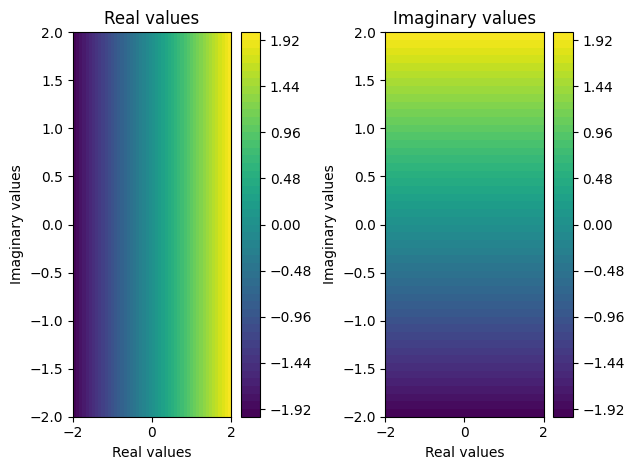

In [45]:
def plot_complex(X, Y, Z, N=50):
    fig, (real_axis, imag_axis) = plt.subplots(1, 2)
    f1 = real_axis.contourf(X, Y, Z.real, N)
    fig.colorbar(f1, ax=real_axis)
    f2 = imag_axis.contourf(X, Y, Z.imag, N)
    fig.colorbar(f2, ax=imag_axis)
    real_axis.set_title("Real values")
    imag_axis.set_title("Imaginary values")
    for ax in [real_axis, imag_axis]:
        ax.set_xlabel("Real values")
        ax.set_ylabel("Imaginary values")
    fig.tight_layout()


plot_complex(X, Y, Z)

We can now apply our visualization function to our simple dispersion relation



In [46]:
# sphinx_gallery_thumbnail_number = 2
F = plasma_dispersion_1D_dist_arr(zetas=Z,
                                  dist=dfunc,
                                  kWave=kWave,
                                  vth=vth,
                                  wp=wp)

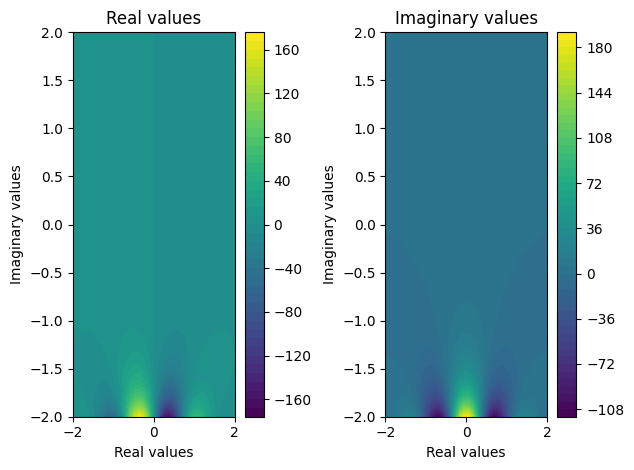

In [47]:
plot_complex(X, Y, F)

Let's find the area where the dispersion function has a lesser than zero real part:

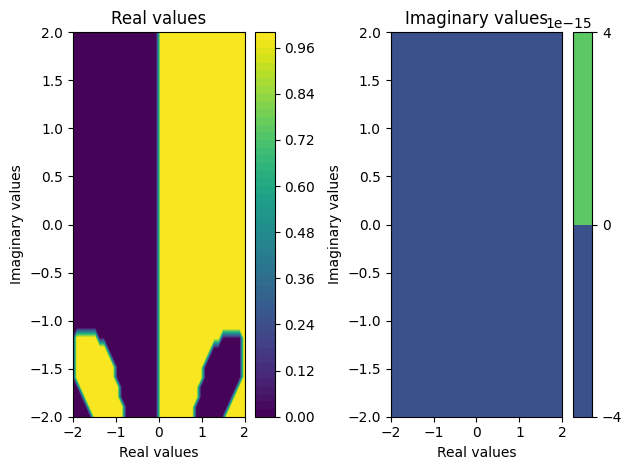

In [48]:
plot_complex(X, Y, F.real < 0)

We can visualize the derivative:

In [49]:
Fp = plasma_dispersion_1D_dist_deriv_arr(zetas=Z,
                                         dist=dfunc,
                                         kWave=kWave,
                                         vth=vth,
                                         wp=wp)

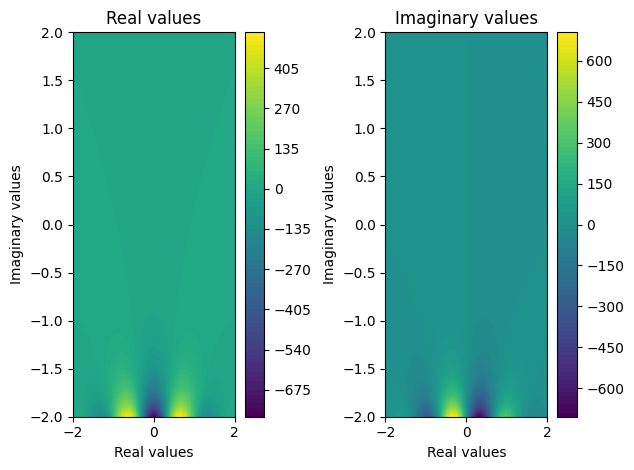

In [50]:
plot_complex(X, Y, Fp, 100)

Now we examine the derivative of the dispersion function as a function of the phase velocity of an electromagnetic wave propagating through the plasma. This is recreating figure 5.1 in J. Sheffield, D. Froula, S. H. Glenzer, and N. C. Luhmann Jr, Plasma scattering of electromagnetic radiation: theory and measurement techniques, ch. 5, p. 106 (Academic press, 2010). We will calculate this using both the generalized dispersion method and the Faddeeva function method, which is specific to Maxwellian plasmas, and tends to be computationally faster.

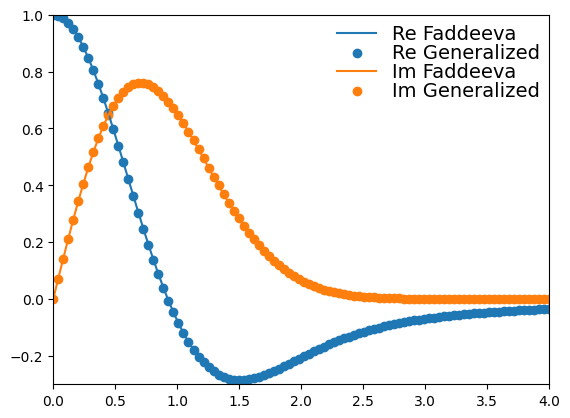

In [51]:
xs = np.linspace(0, 4, 100)
ws_faddeeva = (-1 / 2) * plasma_dispersion_func_deriv(xs)
ws_generalized = (-1 / 2) * plasma_dispersion_1D_dist_deriv_arr(zetas=xs,
                                                                dist=dfunc,
                                                                kWave=kWave,
                                                                vth=vth,
                                                                wp=wp)

plt.plot(xs, ws_faddeeva.real, c='C0', label="Re Faddeeva")
plt.scatter(xs, ws_generalized.real, c='C0', label="Re Generalized")
plt.plot(xs, ws_faddeeva.imag, c='C1', label="Im Faddeeva")
plt.scatter(xs, ws_generalized.imag, c='C1', label="Im Generalized")
plt.axis([0, 4, -0.3, 1])
plt.legend(
    loc="upper right", frameon=False, labelspacing=0.001, fontsize=14, borderaxespad=0.1
)
plt.show()

We can use any 1D distribution function which is well behaved (real, positive valued, differentiable, and integrates to unity). In this case we use the Generalized_Gaussian_1D function to create a super-Gaussian to the power of 5.

In [52]:
p = 5
vp = generalized_gaussian_thermal_speed(Te, p=p, particle=particle)
sg_func = lambda v : Generalized_Gaussian_1D(v=v,
                                             T=Te,
                                             p=p,
                                             particle=particle,
                                             v_drift=0,
                                            )

Let's compare our super-Gaussian distribution to the previous Maxwellian distribution.

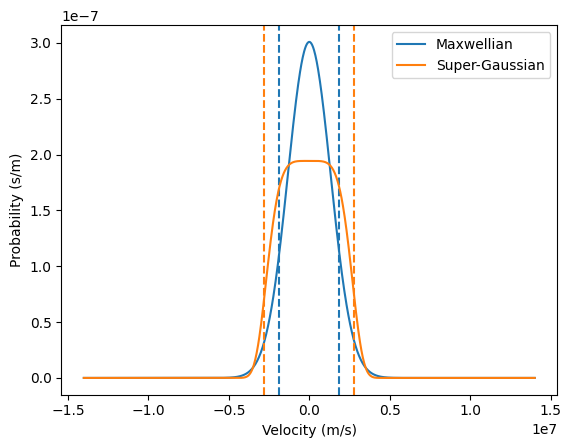

In [53]:
vs = np.linspace(-5*vp, 5*vp, 1000)
mxwl_vals = dfunc(vs)
sg_vals = sg_func(vs)

plt.plot(vs, mxwl_vals, label="Maxwellian")
plt.axvline(-vth.value, ls='--', c='C0')
plt.axvline(vth.value, ls='--', c='C0')
plt.plot(vs, sg_vals, label="Super-Gaussian")
plt.axvline(-vp.value, ls='--', c='C1')
plt.axvline(vp.value, ls='--', c='C1')
plt.xlabel("Velocity (m/s)")
plt.ylabel("Probability (s/m)")
plt.legend()
plt.show()

Above, we have marked the thermal velocity of the Maxwellian and of the Super-Gaussian with vertical dashed lines.

Now let's calculate the dispersion function for the super-Gaussian case and compare it to the Maxwellian case.

In [54]:
xs = np.linspace(0, 4, 100)
ws_faddeeva = (-1 / 2) * plasma_dispersion_func_deriv(xs)
ws_generalized_sg = (-1 / 2) * plasma_dispersion_1D_dist_deriv_arr(zetas=xs,
                                                                   dist=sg_func,
                                                                   kWave=kWave,
                                                                   vth=vp,
                                                                   wp=wp)

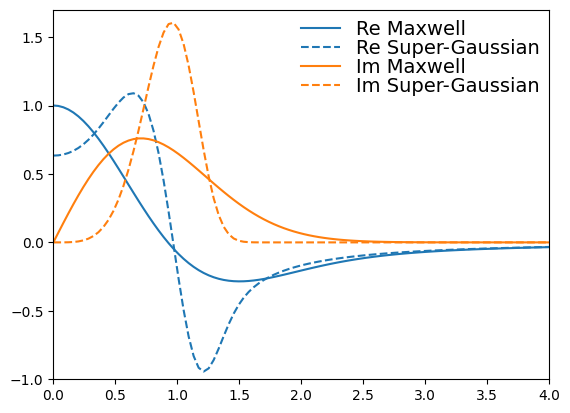

In [55]:
plt.plot(xs, ws_faddeeva.real, c='C0', label="Re Maxwell")
plt.plot(xs, ws_generalized_sg.real, ls='--', c='C0', label="Re Super-Gaussian")
plt.plot(xs, ws_faddeeva.imag, c='C1', label="Im Maxwell")
plt.plot(xs, ws_generalized_sg.imag, ls='--', c='C1', label="Im Super-Gaussian")
plt.axis([0, 4, -1, 1.7])
plt.legend(
    loc="upper right", frameon=False, labelspacing=0.001, fontsize=14, borderaxespad=0.1
)
plt.show()

And now in 2D

In [56]:
S = plasma_dispersion_1D_dist_arr(zetas=Z,
                                  dist=sg_func,
                                  kWave=kWave,
                                  vth=vp,
                                  wp=wp)

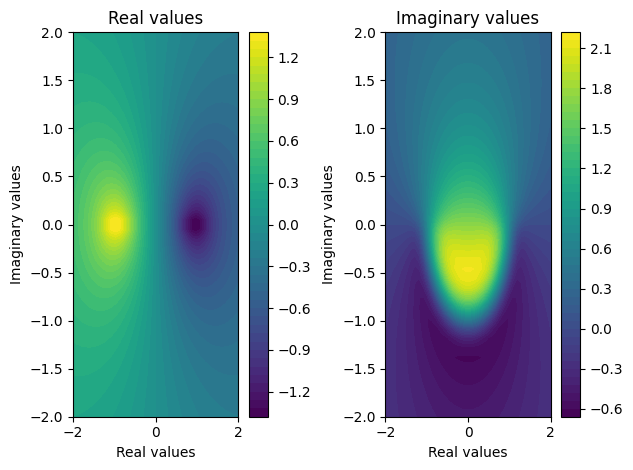

In [57]:
plot_complex(X, Y, S)

In [60]:
Sp = plasma_dispersion_1D_dist_deriv_arr(zetas=Z,
                                         dist=sg_func,
                                         kWave=kWave,
                                         vth=vp,
                                         wp=wp)

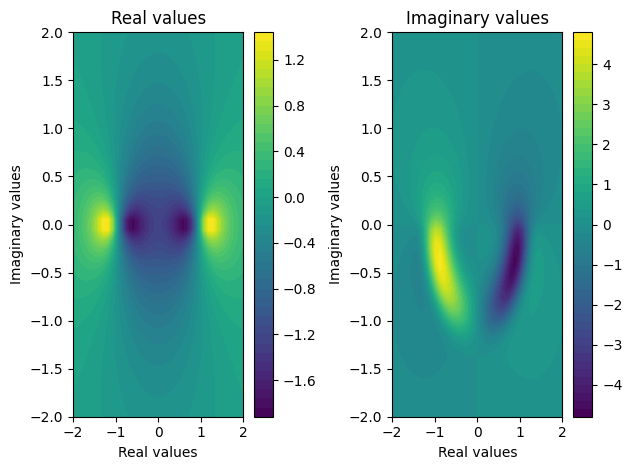

In [61]:
plot_complex(X, Y, Sp)